<a href="https://colab.research.google.com/github/KsiuTretyakova/python_for_ML_ds_task/blob/main/HW8_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

У цьому домашньому завданні ми будемо працювати з набором даних Tips. Нижче інформація про нього.

**Про датасет:**

Tips - це датасет, який містить інформацію про рахунки та чайові в ресторані.

**Колонки датасету:**
- `total_bill` - загальна сума рахунку (долари)
- `tip` - розмір чайових (долари)
- `sex` - стать відвідувача (Male/Female)
- `smoker` - чи курить (Yes/No)
- `day` - день тижня (Thur/Fri/Sat/Sun)
- `time` - час відвідування (Lunch/Dinner)
- `size` - розмір групи (кількість людей)

**Джерело:** Оригінальні дані зібрані в одному з американських ресторанів у 1990-х роках. Скачати і переглянути набір даних можна тут: https://www.kaggle.com/datasets/sakshisatre/tips-dataset

А також ми вже вивантажили файл з даними і завантажили вам у Матеріали до цього модуля.




**1. Завантаження та огляд**

Завантажте датасет Tips (Чайові) з файла у матеріалах `tips.csv`.

Виведіть (кожен пункт оцінюється в 0.5 бала):
- Перші 5 рядків
- Розмір датасету (shape)
- Назви всіх колонок
- Інформацію про типи даних (info)

In [1]:
import pandas as pd

df_origin = pd.read_csv('tips.csv')
df = df_origin.copy()

display("Перші 5 рядків", "-----", df.head())
display("=" * 100)

display("Розмір датасету (shape)", "-----", df.shape)
display("=" * 100)

display("Назви всіх колонок", "-----", df.columns)
display("=" * 100)

display("Інформацію про типи даних (info)", "-----")
display(df.info())

'Перші 5 рядків'

'-----'

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


'===================================================================================================='

'Розмір датасету (shape)'

...

'===================================================================================================='

'Інформацію про типи даних (info)'

'-----'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


None

**2. Базова вибірка даних**

Виберіть та виведіть (кожен пункт оцінюється в 0.5 бала):
- Колонку `total_bill` (загальний рахунок)
- Колонки `total_bill` та `tip` (чайові) разом
- Перші 10 рядків
- Рядок з індексом 5

In [2]:
# Колонку total_bill (загальний рахунок)
df['total_bill']

,total_bill
0,16.99
1,10.34
2,21.01
3,23.68
4,24.59
...,...
239,29.03
240,27.18
241,22.67
242,17.82


In [3]:
# Колонки total_bill та tip (чайові) разом
df[['total_bill', 'tip']]

,total_bill,tip
0,16.99,1.01
1,10.34,1.66
2,21.01,3.50
3,23.68,3.31
4,24.59,3.61
...,...,...
239,29.03,5.92
240,27.18,2.00
241,22.67,2.00
242,17.82,1.75


In [4]:
# Перші 10 рядків
df.head(10)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


In [5]:
# Рядок з індексом 5 (перший спосіб)
df.loc[5]

,5
total_bill,25.29
tip,4.71
sex,Male
smoker,No
day,Sun
time,Dinner
size,4


In [6]:
# Рядок з індексом 5 (другий спосіб)
df[5:6]

,total_bill,tip,sex,smoker,day,time,size
5,25.29,4.71,Male,No,Sun,Dinner,4


**3. Фільтрація даних**

Відфільтруйте повний набір даних та виведіть (кожен пункт оцінюється в 0.5 бала):
- Всі рахунки більше 20 доларів (`total_bill > 20`)
- Всі відвідувачі-жінки (`sex == 'Female'`)
- Рахунки на вечерю (`time == 'Dinner'`)
- Рахунки на вечерю з сумою чеку більше 30 доларів

Для виведення результатів фільтрації:
- зберегти результат у окрему змінну
- показати кількість записів у відфільтрованому наборі
- вивести перші 5 записів відфільтрованого набору.

In [7]:
# Всі рахунки більше 20 доларів (total_bill > 20)
df[df['total_bill'] > 20]

,total_bill,tip,sex,smoker,day,time,size
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
7,26.88,3.12,Male,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
237,32.83,1.17,Male,Yes,Sat,Dinner,2
238,35.83,4.67,Female,No,Sat,Dinner,3
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2


In [8]:
# Всі відвідувачі-жінки (sex == 'Female')
df[df['sex'] == "Female"]

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
11,35.26,5.00,Female,No,Sun,Dinner,4
14,14.83,3.02,Female,No,Sun,Dinner,2
16,10.33,1.67,Female,No,Sun,Dinner,3
...,...,...,...,...,...,...,...
226,10.09,2.00,Female,Yes,Fri,Lunch,2
229,22.12,2.88,Female,Yes,Sat,Dinner,2
238,35.83,4.67,Female,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2


In [9]:
# Рахунки на вечерю (time == 'Dinner')
df[df['time'] == "Dinner"]

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [10]:
# Рахунки на вечерю з сумою чеку більше 30 доларів
df[(df.total_bill > 30) & (df.time == "Dinner")]

,total_bill,tip,sex,smoker,day,time,size
11,35.26,5.00,Female,No,Sun,Dinner,4
23,39.42,7.58,Male,No,Sat,Dinner,4
39,31.27,5.00,Male,No,Sat,Dinner,3
44,30.40,5.60,Male,No,Sun,Dinner,4
47,32.40,6.00,Male,No,Sun,Dinner,4
52,34.81,5.20,Female,No,Sun,Dinner,4
56,38.01,3.00,Male,Yes,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
95,40.17,4.73,Male,Yes,Fri,Dinner,4
102,44.30,2.50,Female,Yes,Sat,Dinner,3


---

**4. Описова статистика**

Обчисліть (кожен пункт оцінюється в 0.5 бала):
- Середній розмір рахунку на всьому наборі даних
- Максимальні чайові
- Кількість пропущених значень у всіх колонках
- Скільки в наборі даних рахунків за обіди і за вечері

In [11]:
# Середній розмір рахунку на всьому наборі даних
float(df.total_bill.mean().round(2))

19.79

In [12]:
# Максимальні чайові
df.tip.max()

10.0

In [13]:
# Кількість пропущених значень у всіх колонках
df.isna().sum()
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


In [14]:
# Скільки в наборі даних рахунків за обіди і за вечері
df['time'].value_counts()

,count
time,
Dinner,176
Lunch,68


<Axes: >

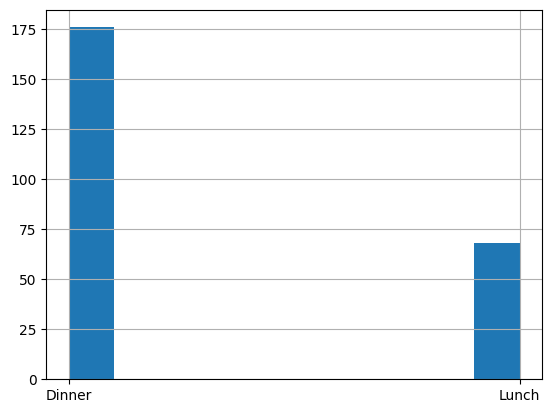

In [15]:
# Скільки в наборі даних рахунків за обіди і за вечері
df['time'].hist()

---

**5. Статистика із групуванням**

Обчисліть (кожен пункт оцінюється в 0.5 бала):
- Середній рахунок за статтю (groupby `sex`)
- Середні чайові за днем тижня (groupby `day`)
- Скільки відвідувачів у кожен день

In [16]:
# Середній рахунок за статтю (groupby sex)
df.groupby('sex')['total_bill'].mean().round(2)

,total_bill
sex,
Female,18.06
Male,20.74


In [17]:
# Середні чайові за днем тижня (groupby day)
df.groupby('day')['tip'].mean().round(2)

,tip
day,
Fri,2.73
Sat,2.99
Sun,3.26
Thur,2.77


In [18]:
# Скільки відвідувачів у кожен день
df.groupby('day')['size'].sum()

,size
day,
Fri,40
Sat,219
Sun,216
Thur,152


---

**6. Створення нової колонки**

Створіть нову колонку `tip_percentage` - відсоток чайових від загальної суми рахунку.
Виведіть перші 10 рядків з новою колонкою.

In [19]:
df['tip_percentage'] = (df.tip / df.total_bill * 100).round(1)
df.head(10)

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,5.9
1,10.34,1.66,Male,No,Sun,Dinner,3,16.1
2,21.01,3.50,Male,No,Sun,Dinner,3,16.7
3,23.68,3.31,Male,No,Sun,Dinner,2,14.0
4,24.59,3.61,Female,No,Sun,Dinner,4,14.7
5,25.29,4.71,Male,No,Sun,Dinner,4,18.6
6,8.77,2.00,Male,No,Sun,Dinner,2,22.8
7,26.88,3.12,Male,No,Sun,Dinner,4,11.6
8,15.04,1.96,Male,No,Sun,Dinner,2,13.0
9,14.78,3.23,Male,No,Sun,Dinner,2,21.9


---

**7. Сортування**

Відсортуйте датасет і виведіть результат сортування в кожному випадку окремо (кожен пункт оцінюється в 0.5 бала):
- За розміром рахунку (зростання)
- За чайовими (спадання)

Додатково виведіть топ-5 найбільших чайових використовуючи метод `nlargest`.

In [20]:
# За розміром рахунку (зростання)
df.sort_values('total_bill')

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
67,3.07,1.00,Female,Yes,Sat,Dinner,1,32.6
92,5.75,1.00,Female,Yes,Fri,Dinner,2,17.4
111,7.25,1.00,Female,No,Sat,Dinner,1,13.8
172,7.25,5.15,Male,Yes,Sun,Dinner,2,71.0
149,7.51,2.00,Male,No,Thur,Lunch,2,26.6
...,...,...,...,...,...,...,...,...
182,45.35,3.50,Male,Yes,Sun,Dinner,3,7.7
156,48.17,5.00,Male,No,Sun,Dinner,6,10.4
59,48.27,6.73,Male,No,Sat,Dinner,4,13.9
212,48.33,9.00,Male,No,Sat,Dinner,4,18.6


In [21]:
# За чайовими (спадання)
df.sort_values('tip', ascending=False)

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
170,50.81,10.00,Male,Yes,Sat,Dinner,3,19.7
212,48.33,9.00,Male,No,Sat,Dinner,4,18.6
23,39.42,7.58,Male,No,Sat,Dinner,4,19.2
59,48.27,6.73,Male,No,Sat,Dinner,4,13.9
141,34.30,6.70,Male,No,Thur,Lunch,6,19.5
...,...,...,...,...,...,...,...,...
0,16.99,1.01,Female,No,Sun,Dinner,2,5.9
111,7.25,1.00,Female,No,Sat,Dinner,1,13.8
92,5.75,1.00,Female,Yes,Fri,Dinner,2,17.4
67,3.07,1.00,Female,Yes,Sat,Dinner,1,32.6


In [22]:
# За розміром рахунку (зростання) та за чайовими (спадання)
df.sort_values(['total_bill', 'tip'], ascending=[True, False])

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
67,3.07,1.00,Female,Yes,Sat,Dinner,1,32.6
92,5.75,1.00,Female,Yes,Fri,Dinner,2,17.4
172,7.25,5.15,Male,Yes,Sun,Dinner,2,71.0
111,7.25,1.00,Female,No,Sat,Dinner,1,13.8
149,7.51,2.00,Male,No,Thur,Lunch,2,26.6
...,...,...,...,...,...,...,...,...
182,45.35,3.50,Male,Yes,Sun,Dinner,3,7.7
156,48.17,5.00,Male,No,Sun,Dinner,6,10.4
59,48.27,6.73,Male,No,Sat,Dinner,4,13.9
212,48.33,9.00,Male,No,Sat,Dinner,4,18.6


In [23]:
# Додатково виведіть топ-5 найбільших чайових використовуючи метод nlargest.
df.nlargest(5, 'tip')

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
170,50.81,10.00,Male,Yes,Sat,Dinner,3,19.7
212,48.33,9.00,Male,No,Sat,Dinner,4,18.6
23,39.42,7.58,Male,No,Sat,Dinner,4,19.2
59,48.27,6.73,Male,No,Sat,Dinner,4,13.9
141,34.30,6.70,Male,No,Thur,Lunch,6,19.5


In [24]:
# Додатково виведіть топ-5 найбільших чайових використовуючи метод nlargest.
df.nlargest(5, 'tip')['tip']

,tip
170,10.00
212,9.00
23,7.58
59,6.73
141,6.70
